In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.integrate import solve_ivp
import itertools
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# 1. Load the data (which the R script previously converted to g/cm^3)
df = pd.read_csv("GSE124821_data_1e8.csv")

# 2. Dynamically grep all columns containing 'quanTIseq'
quanTIseq_cols = [col for col in df.columns if 'quanTIseq' in col]

# 3. Define the masses used in the R script to reverse-engineer the fractions
masses_g = {
    "Dendritic_quanTIseq": 6e-10,
    "NK_quanTIseq": 6e-10,
    "T.CD8_quanTIseq": 2e-10,
    "Tregs_quanTIseq": 2e-10
}
total_cell_density = 1e8
cancer_cell_mass_g = 8e-9 # Based on C_M = 0.8 g/cm^3 at 1e8 cells

# 4. Reverse the R-script math to get the raw fractions back
df_fractions = pd.DataFrame()
for col in quanTIseq_cols:
    df_fractions[col] = df[col] / (masses_g[col] * total_cell_density)

# 5. Calculate Cancer Fraction (1 - sum of immune fractions)
cancer_fraction = (1.0 - df_fractions.sum(axis=1)).clip(lower=0)

# 6. Convert Cancer Fraction back into Mass Density (g/cm^3)
df['Cancer'] = cancer_fraction * total_cell_density * cancer_cell_mass_g

In [2]:
# Splitting Data and Extracting Series
# Train - validation split
df["strata"] = df["Mouse_treatment"] + "_" + df["Timepoint"]

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["strata"],
    random_state=SEED
)

# Extract time series averages
def extract_series(data):
    Cs, Ds, NKs, T8s, Trs = [], [], [], [], []
    for day in ["day3","day7"]:
        subset = data[data["Timepoint"] == day]
        # Make sure we grab our newly derived 'Cancer' column!
        Cs.append(subset["Cancer"].mean())
        Ds.append(subset["Dendritic_quanTIseq"].mean())
        NKs.append(subset["NK_quanTIseq"].mean())
        T8s.append(subset["T.CD8_quanTIseq"].mean())
        Trs.append(subset["Tregs_quanTIseq"].mean())

    return np.array(Cs), np.array(Ds), np.array(NKs), np.array(T8s), np.array(Trs)

C_train, D_train, NK_train, T8_train, Tr_train = extract_series(train_df)
C_val, D_val, NK_val, T8_val, Tr_val = extract_series(val_df)

# Initial conditions from day 3
y0_train = [C_train[0], D_train[0], NK_train[0], Tr_train[0], T8_train[0]]
y0_val   = [C_val[0], D_val[0], NK_val[0], Tr_val[0], T8_val[0]]

In [4]:
# ODE model
def cancer_ode(t,y,p):

    C,D,N,Tr,T8 = y

    dC = p["lambda_C"]*C*(1-C/p["C_M"]) - p["eta_8"]*T8*C - p["eta_N"]*N*C - p["d_C"]*C
    dD = p["lambda_DC_comb"]*C/(C+p["K_C"]) - p["d_D"]*D

    dN = (
        p["sigma_N"]
        - p["d_N"]*N
        - p["gamma_N"]*Tr*N
        + p["a_C"]*N*C/(1 + C/p["beta_1"] + N/p["beta_2"])
    )

    dTr = -p["d_Tr"]*Tr + p["lambda_Tr_comb"]*C/(p["K_C"]+C)

    dT8 = -p["d_T8"]*T8 + p["lambda_T8_comb"]*D/(p["K_D"]+D)/(1+Tr/p["K_Tr"])

    return [dC,dD,dN,dTr,dT8]

In [5]:
# baes_params
base_params = {
    "lambda_C":1.5,
    "C_M":0.8,
    "eta_8":328.55,
    "eta_N":300,
    "d_C":0.17,

    "lambda_DC_comb":8e-5,
    "K_C":0.4,
    "d_D":0.1,

    "sigma_N":5e-5,
    "d_N":0.1,
    "gamma_N":150,
    "a_C":0.5,
    "beta_1":0.4,
    "beta_2":2e-4,

    "d_Tr":0.2,
    "lambda_Tr_comb":2e-4,

    "d_T8":0.18,
    "lambda_T8_comb":0.00108,
    "K_Tr":2.5e-4,
    "K_D":4e-4
}

In [8]:
# Grid search parameter ranges
param_grid = {
    "lambda_DC_comb":[5e-4,7.5e-4,1e-3],
    "sigma_N":[5e-5,1e-4,2e-4,3e-4],
    "lambda_T8_comb":[1e-5,5e-5,1e-4],
    "d_T8":[0.075,0.1,0.18,0.25],
    "K_Tr":[1e-11,1e-8,1e-6],
    "d_N":[0.1,0.15,0.2]
}

In [9]:
# Relative Error metric & Grid Search Fitting
# Relative RMSE function
def rmse_rel(pred, true):
    # Dividing by 'true' makes the error relative (e.g. 10% off), 
    # preventing the massive cancer scale from dominating the optimizer.
    # We add 1e-9 to avoid dividing by absolute zero.
    return np.sqrt(np.mean(((pred - true) / (true + 1e-9))**2))

# Grid search on training set
best_params = None
best_error = np.inf

keys = param_grid.keys()
values = param_grid.values()

for combo in itertools.product(*values):
    params = base_params.copy()
    for k,v in zip(keys,combo):
        params[k] = v

    sol = solve_ivp(
        lambda t,y: cancer_ode(t,y,params),
        (0,7),
        y0_train,
        t_eval=[3,7]
    )

    pred = sol.y[:,1]
    
    # We are finally tracking all 5 cell lines, including Cancer!
    true = np.array([
        C_train[1],
        D_train[1],
        NK_train[1],
        Tr_train[1],
        T8_train[1]
    ])

    error = rmse_rel(pred, true)

    if error < best_error:
        best_error = error
        best_params = params.copy()

print(f"Best Relative Error: {best_error:.4f}")

Best Relative Error: 0.4293


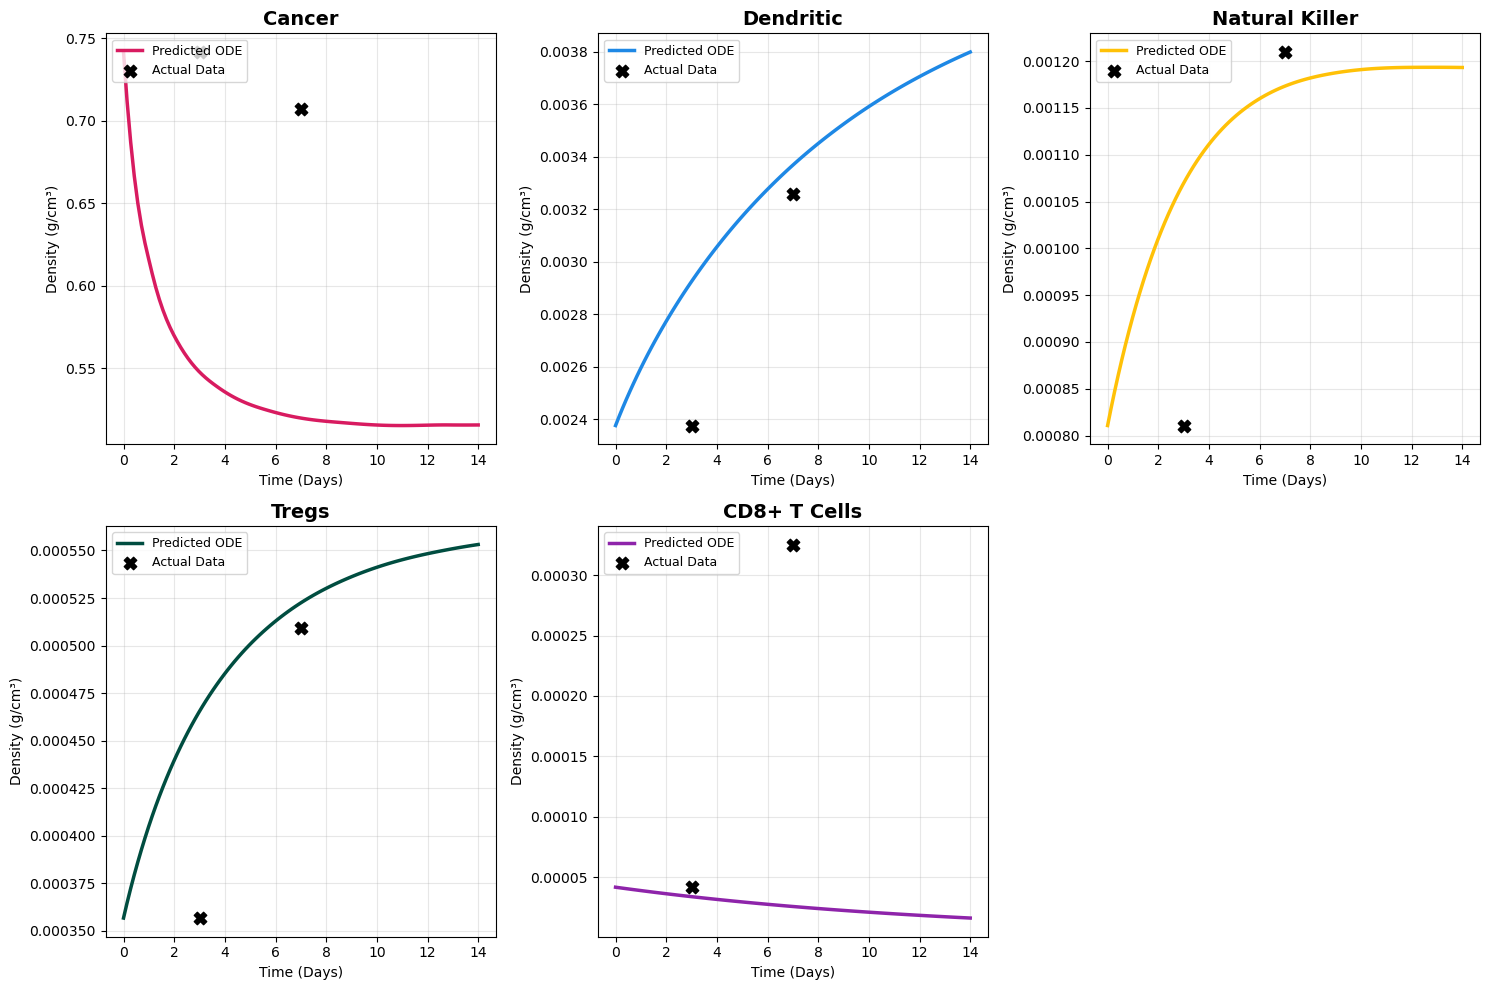

In [10]:
# The improved subplot presentation
# 1. Run the optimal model over 14 days with 100 timepoints for a smooth line
t_smooth = np.linspace(0, 14, 100)
sol_plot = solve_ivp(
    lambda t, y: cancer_ode(t, y, best_params),
    (0, 14),
    y0_train,
    t_eval=t_smooth
)

# 2. Ordered list matching your ODE returns: [dC, dD, dN, dTr, dT8]
cell_labels = ['Cancer', 'Dendritic', 'Natural Killer', 'Tregs', 'CD8+ T Cells']

# Actual training data points for Day 3 and Day 7
actual_t = [3, 7]
actual_data = [C_train, D_train, NK_train, Tr_train, T8_train]

# 3. Create the 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

colors = ['#D81B60', '#1E88E5', '#FFC107', '#004D40', '#8E24AA']

for i, cell_name in enumerate(cell_labels):
    ax = axes[i]
    
    # Plot predicted ODE line
    ax.plot(sol_plot.t, sol_plot.y[i], label='Predicted ODE', color=colors[i], linewidth=2.5)
    
    # Plot actual data points
    ax.scatter(actual_t, actual_data[i], label='Actual Data', color='black', s=80, zorder=5, marker='X')
    
    ax.set_title(cell_name, fontsize=14, fontweight='bold')
    ax.set_xlabel("Time (Days)")
    ax.set_ylabel("Density (g/cm³)")
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide the empty 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()